In [1]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)

In [2]:
import matplotlib.pyplot as plt
import cmocean.cm as cmo
import xarray as xr
from xmitgcm import open_mdsdataset
import numpy as np

data_dir = '/data/SO3/edavenport/tpose6/apr2013/run_sens_surface/'
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'

num_diags = 122 #
itPerFile = 72 # 1 day
intervals = range(0,itPerFile*num_diags,itPerFile) # adjoint sensitivity will start at 0 and go to 1 lag (1 interval less than total number of timesteps)
prefix = ['ADJetan','ADJtaux','ADJqnet']
# when prefix is not set, this will read all available files 
# have to ignore unkown vars until we have an available_diagnostics.log that includes ADJrhoinsitu
tpose_ds = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,prefix=prefix,iters=intervals,ref_date='2013-04-01',delta_t=1200,ignore_unknown_vars=True)
tpose_ds['XC'] = tpose_ds.XC.astype(float)
tpose_ds['YC'] = tpose_ds.YC.astype(float)
tpose_ds['Z'] = tpose_ds.Z.astype(float)
tpose_ds['XG'] = tpose_ds.XG.astype(float)
tpose_ds['YG'] = tpose_ds.YG.astype(float)

### Select Region

In [3]:
# tpose_ds.ADJetan is t, xc, yc
lat_min = -3
lat_max = 3
lon_min = 170 #170E
lon_max = 260 #100W

tpose_ds = tpose_ds.sel(XC=slice(lon_min,lon_max),YC=slice(lat_min,lat_max),XG=slice(lon_min,lon_max),YG=slice(lat_min,lat_max))

### Meridional Average

In [4]:
ADJetan = tpose_ds.ADJetan
ADJtaux = tpose_ds.ADJtaux
ADJqnet = tpose_ds.ADJqnet

### Temporal Demean and Detrend

In [5]:
from scipy.signal import detrend

ADJetan_detrend = detrend(ADJetan, axis=0)
ADJtaux_detrend = detrend(ADJtaux, axis=0)
ADJqnet_detrend = detrend(ADJqnet, axis=0)

# copy into data array
ADJetan_detrend = xr.DataArray(ADJetan_detrend, coords=ADJetan.coords, dims=ADJetan.dims)
ADJtaux_detrend = xr.DataArray(ADJtaux_detrend, coords=ADJtaux.coords, dims=ADJtaux.dims)
ADJqnet_detrend = xr.DataArray(ADJqnet_detrend, coords=ADJqnet.coords, dims=ADJqnet.dims)

# demean
ADJetan_anom = ADJetan_detrend - ADJetan_detrend.mean(dim='time')
ADJtaux_anom = ADJtaux_detrend - ADJtaux_detrend.mean(dim='time')
ADJqnet_anom = ADJqnet_detrend - ADJqnet_detrend.mean(dim='time')

### Calculate Symmetric and Antisymmetric

In [6]:
# simpler: manually select +y and -y
pos = ADJetan_anom.sel(YC=ADJetan_anom.YC[ADJetan_anom.YC>=0]).values
neg = ADJetan_anom.sel(YC=ADJetan_anom.YC[ADJetan_anom.YC<=0]).values

# flip neg to align with pos
neg_flipped = neg[::-1]

# symmetric
sym = 0.5 * (pos + neg_flipped)
# antisymmetric
anti = 0.5 * (pos - neg_flipped)

ADJetan_anom_sym = xr.DataArray(sym, coords=ADJetan_anom.sel(YC=ADJetan_anom.YC[ADJetan_anom.YC>=0]).coords, dims=ADJetan_anom.sel(YC=ADJetan_anom.YC[ADJetan_anom.YC>=0]).dims)
ADJetan_anom_anti = xr.DataArray(anti, coords=ADJetan_anom.sel(YC=ADJetan_anom.YC[ADJetan_anom.YC>=0]).coords, dims=ADJetan_anom.sel(YC=ADJetan_anom.YC[ADJetan_anom.YC>=0]).dims)
ADJetan_anom_sym = ADJetan_anom_sym.mean(dim='YC')
ADJetan_anom_anti = ADJetan_anom_anti.mean(dim='YC')
ADJetan_anom = ADJetan_anom.mean(dim='YC')


In [ ]:
ADJetan_anom_sym

### Window (in X and T)

In [7]:
# use a hanning window in t and x dimensions
window_t = np.hanning(ADJetan_anom.shape[0])
window_x = np.hanning(ADJetan_anom.shape[1])
window_2d = np.outer(window_t, window_x)
ADJetan_windowed = ADJetan_anom * window_2d
ADJetan_sym_windowed = ADJetan_anom_sym * window_2d
ADJetan_anti_windowed = ADJetan_anom_anti * window_2d
# ADJqnet_windowed = ADJqnet_anom * window_2d

# window_t = np.hanning(ADJtaux_anom.shape[0])
# window_x = np.hanning(ADJtaux_anom.shape[1])
# window_2d = np.outer(window_t, window_x)
# ADJtaux_windowed = ADJtaux_anom * window_2d

In [8]:
folder_name = '/home/edavenport/analysis/TPOSE6_Sensitivity/apr2013/surface/'

### 2-D FFT 

In [9]:
# -----------------------------
# Get time and space units (dt and dx) from coordinates
# -----------------------------

dx = np.mean(np.diff(tpose_ds.XC))  # in units of degrees
dt_ns = np.mean(np.diff(tpose_ds.time))              # timedelta64[ns]
dt = dt_ns / np.timedelta64(1, 'D') # convert to float in days

print(dt)    # 1 day
print(dx)    # 1/6 degree


1.0
0.16666665723018612


In [10]:

# # -----------------------------
# # 2D FFT
# # -----------------------------
ETAN_fft = np.fft.fft2(ADJetan_windowed)
ETAN_fft = np.fft.fftshift(ETAN_fft, axes=(0,1))  # shift time and lon axes
Nt = ADJetan_windowed.shape[0]
Nx = ADJetan_windowed.shape[1]
P = np.abs(ETAN_fft)**2 / (Nt*Nx)

ETAN_sym_fft = np.fft.fft2(ADJetan_sym_windowed)
ETAN_sym_fft = np.fft.fftshift(ETAN_sym_fft, axes=(0,1))  # shift time and lon axes
P_sym = np.abs(ETAN_sym_fft)**2 / (Nt*Nx)

ETAN_anti_fft = np.fft.fft2(ADJetan_anti_windowed)
ETAN_anti_fft = np.fft.fftshift(ETAN_anti_fft, axes=(0,1))  # shift time and lon axes
P_anti = np.abs(ETAN_anti_fft)**2 / (Nt*Nx)

In [63]:
# wavenumber / frequency axes
kx = np.fft.fftshift(np.fft.fftfreq(Nx, d=dx))        # deg^-1
omega = np.fft.fftshift(np.fft.fftfreq(Nt, d=dt)) # cycles/day
omega_rad_per_day = 2*np.pi*omega

In [65]:
# -----------------------------
# Normalize for real signal
# -----------------------------
# double all non-zero, non-Nyquist frequencies along time
nonzero_idx = np.where((omega != 0) & (omega != omega.max()))[0]
P[nonzero_idx, :] *= 2

# -----------------------------
# Select only positive omega
# -----------------------------
pos_idx = omega >= 0
P_pos = P[pos_idx, :]
omega_pos = omega[pos_idx]
omega_rad_per_day_pos = omega_rad_per_day[pos_idx]

# Create xarray for plotting
P_da = xr.DataArray(P_pos, dims=['omega','kx'],
                    coords={'omega': omega_rad_per_day_pos, 'kx': kx})

P_sym[nonzero_idx, :] *= 2

# -----------------------------
# Select only positive omega
# -----------------------------
pos_idx = omega >= 0
P_pos = P_sym[pos_idx, :]

# Create xarray for plotting
P_da_sym = xr.DataArray(P_pos, dims=['omega','kx'],
                    coords={'omega': omega_rad_per_day_pos, 'kx': kx})

P_anti[nonzero_idx, :] *= 2

# -----------------------------
# Select only positive omega
# -----------------------------
pos_idx = omega >= 0
P_pos = P_anti[pos_idx, :]
# Create xarray for plotting
P_da_anti = xr.DataArray(P_pos, dims=['omega','kx'],
                    coords={'omega': omega_rad_per_day_pos, 'kx': kx})

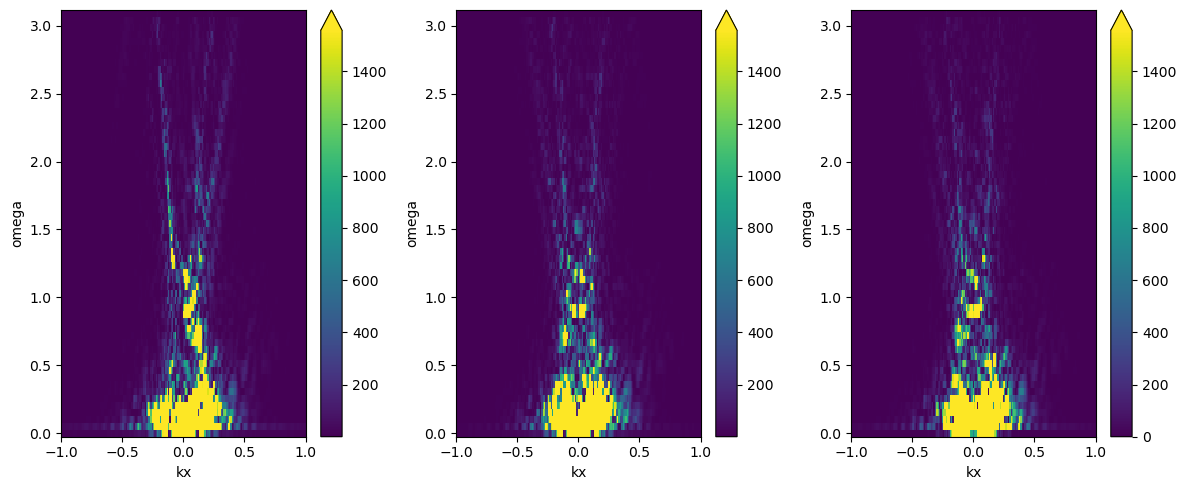

In [68]:
fig, ax = plt.subplots(figsize=(12,5),ncols=3)
P_da.plot(ax=ax[0],x='kx', y='omega', cmap='viridis',vmax=np.percentile(P_da, 99))
ax[0].set_xlim(-1,1)
# ax[0].set_ylim(0,0.5)
P_da_sym.plot(ax=ax[1],x='kx', y='omega', cmap='viridis',vmax=np.percentile(P_da, 99))
ax[1].set_xlim(-1,1)
# ax[1].set_ylim(0,0.5)
P_da_anti.plot(ax=ax[2],x='kx', y='omega', cmap='viridis',vmax=np.percentile(P_da, 99))
ax[2].set_xlim(-1,1)
# ax[2].set_ylim(0,0.5)
plt.tight_layout()

In [107]:
# -----------------------------
# Physical constants
# -----------------------------
g = 9.81            # m/s^2
beta = 2.3e-11      # 1/(m s)
c1 = 2.5
c2 = 1.4
deg2m = 111320      # m per degree at equator
c_barotropic = np.sqrt(9.81*4000)  # m/s


In [95]:
# # --- Dispersion relations --- in rad/s
def omega_kelvin_fn(k, c): 
#     # Kelvin waves exist for eastward (positive k) only
    omega = np.zeros_like(k)
    omega[k>=0] = c*k[k>=0]
    omega[k<0] = np.nan  # optional: don't plot Kelvin for negative k
    return omega

def omega_yanai(k, c, beta): 
    return 0.5*(c*k - np.sqrt((c*k)**2 + 4*beta*c))

def omega_yanai_east(k, c, beta): 
    return 0.5*(c*k + np.sqrt((c*k)**2 + 4*beta*c))

def omega_rossby_fn(k, n, c, beta): 
    return - beta*k / (k**2 + (2*n + 1)*beta/c)

def omega_IG(k, n, c, beta): 
    return np.sqrt(c**2 * k**2 + (2*n + 1)*beta*c)

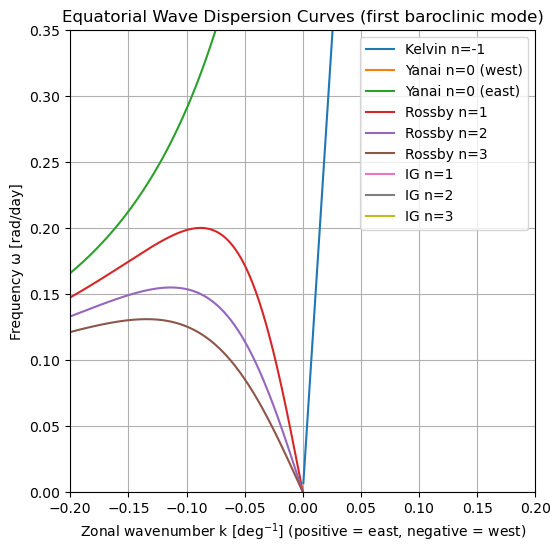

In [96]:
deg2m = 111320      # m per degree at equator

# -----------------------------
# Wavenumber array (signed)
# -----------------------------
k_deg = np.linspace(-0.5, 0.5, 1000)   # deg^-1
k_m = k_deg / deg2m                     # convert to 1/m
k_rad = 2*np.pi * k_m  # now in rad/m

# --- Plotting ---
plt.figure(figsize=(6,6))

# Kelvin (eastward only)
plt.plot(k_deg, omega_kelvin_fn(k_rad, c1)*86400, label="Kelvin n=-1")

# Yanai
plt.plot(k_deg, omega_yanai(k_rad, c1, beta)*86400, label="Yanai n=0 (west)")
plt.plot(k_deg, omega_yanai_east(k_rad, c1, beta)*86400, label="Yanai n=0 (east)")

# Rossby n=1..3
for n in [1,2,3]:
    plt.plot(k_deg, omega_rossby_fn(k_rad, n, c1, beta)*86400, label=f"Rossby n={n}")

# IG n=1..3
for n in [1,2,3]:
    plt.plot(k_deg, omega_IG(k_rad, n, c1, beta)*86400, label=f"IG n={n}")

plt.xlabel("Zonal wavenumber k [deg$^{-1}$] (positive = east, negative = west)")
plt.ylabel("Frequency ω [rad/day]")
plt.title("Equatorial Wave Dispersion Curves (first baroclinic mode)")
plt.legend()
plt.xlim(-0.2, 0.2)
plt.ylim(0, 0.35)
plt.grid(True)
plt.show()

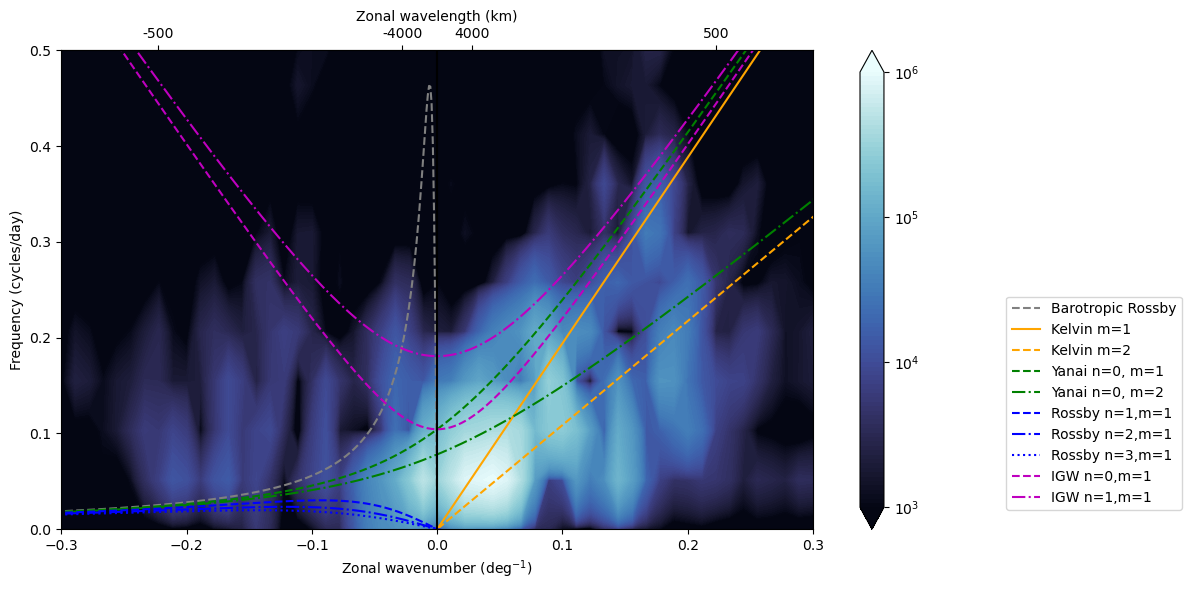

In [108]:
deg2m = 111320      # m per degree at equator

# -----------------------------
# Wavenumber array (signed)
# -----------------------------
k_deg = np.linspace(-0.5, 0.5, 1000)   # deg^-1
k_m = k_deg / deg2m                     # convert to 1/m
k_rad = 2*np.pi * k_m  # now in rad/m

omega_barotropic = -beta * k_rad / (k_rad**2 + 1 * beta / c_barotropic)  # rad/s
freq_barotropic_ross = omega_barotropic * 86400 / (2*np.pi)  # cycles/day

from matplotlib.colors import LogNorm
log_levels = np.logspace(3, 6, 100)
fig, ax = plt.subplots(figsize=(12,6))
cf = P_da.plot.contourf(ax=ax,x='kx', y='omega', cmap=cmo.ice,levels=log_levels,extend='both',norm=LogNorm(vmin=1e3,vmax=1e6))

# set log scale ticks for colorbar
cbar = cf.colorbar
cbar.set_ticks([1000, 10000, 100000, 1000000])

ax.set_ylabel('Frequency (cycles/day)')
ax.set_xlabel('Zonal wavenumber (deg$^{-1}$)')
# Overlay dispersion curves
ax.plot(k_deg, freq_barotropic_ross, color='gray', linestyle='--', label='Barotropic Rossby')
ax.plot(k_deg, omega_kelvin_fn(k_rad, c1)*86400/(2*np.pi), color='orange', label='Kelvin m=1')
ax.plot(k_deg, omega_kelvin_fn(k_rad, c2)*86400/(2*np.pi), color='orange', linestyle='--',label='Kelvin m=2')
ax.plot(k_deg, omega_yanai_east(k_rad, c1, beta)*86400/(2*np.pi), color='green', linestyle='--',label='Yanai n=0, m=1')
ax.plot(k_deg, omega_yanai_east(k_rad, c2, beta)*86400/(2*np.pi), color='green', linestyle='-.', label='Yanai n=0, m=2')
ax.plot(k_deg, omega_rossby_fn(k_rad, 1, c1, beta)*86400/(2*np.pi), color='blue', linestyle='--', label='Rossby n=1,m=1')
ax.plot(k_deg, omega_rossby_fn(k_rad, 2, c1, beta)*86400/(2*np.pi), color='blue', linestyle='-.', label='Rossby n=2,m=1')
ax.plot(k_deg, omega_rossby_fn(k_rad, 3, c1, beta)*86400/(2*np.pi), color='blue', linestyle=':', label='Rossby n=3,m=1')
ax.plot(k_deg, omega_IG(k_rad, 0, c1, beta)*86400/(2*np.pi), color='m', linestyle='--', label='IGW n=0,m=1')
ax.plot(k_deg, omega_IG(k_rad, 1, c1, beta)*86400/(2*np.pi), color='m', linestyle='-.', label='IGW n=1,m=1')
# ax.plot(k_deg, omega_IG(k_rad, 0, c2, beta)*86400/(2*np.pi), color='m', linestyle=':', label='IGW n=0,m=2')
# ax.plot(k_deg, omega_IG(k_rad, 1, c2, beta)*86400/(2*np.pi), color='m', label='IGW n=1,m=2')
ax.axvline(0, color='k',label='_nolabel')
ax.legend(bbox_to_anchor=(1.5, 0.5))

# Manually set secondary x-axis ticks
km_ticks = np.array([-4000, -500, 500, 4000])  # desired top-axis tick labels in km
kdeg_for_ticks = deg2m / (1000 * km_ticks)     # convert km → k_deg
# Set secondary axis manually with fixed tick positions
secax = ax.secondary_xaxis('top')
secax.set_xticks(kdeg_for_ticks)                  # positions in deg^-1
secax.set_xticklabels([str(int(wl)) for wl in km_ticks])  # labels in km
secax.set_xlabel('Zonal wavelength (km)')

ax.set_xlim(-0.3,0.3)
ax.set_ylim(0,0.5)

plt.tight_layout()
fig.savefig(folder_name + 'k_omega_spectrum_ETAN.png', dpi=300)

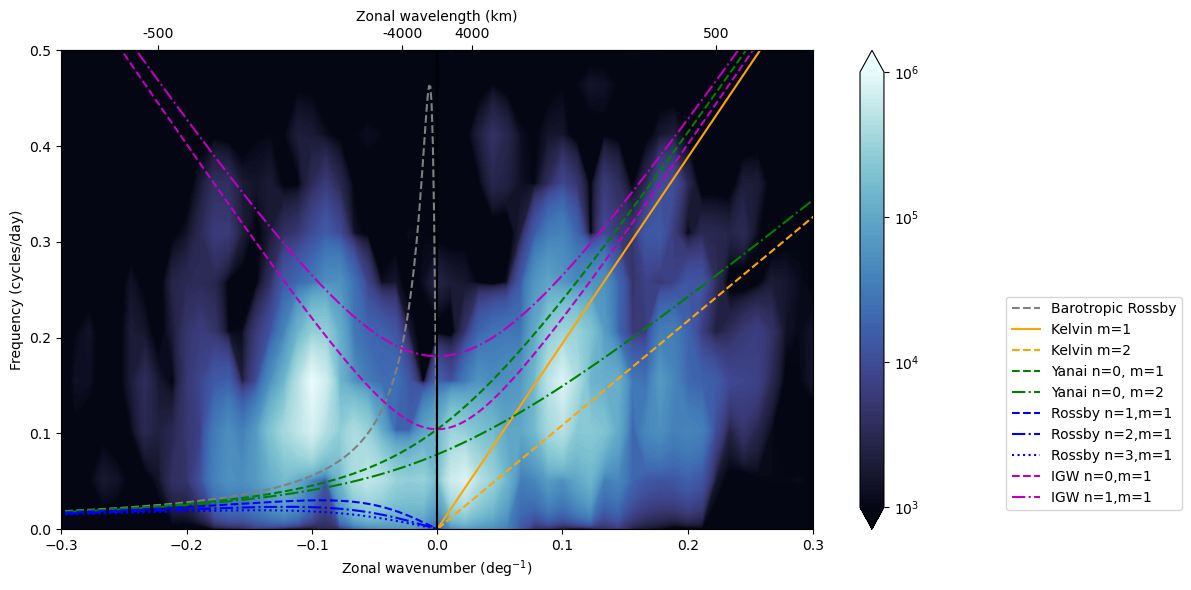

In [109]:
deg2m = 111320      # m per degree at equator

# -----------------------------
# Wavenumber array (signed)
# -----------------------------
k_deg = np.linspace(-0.5, 0.5, 1000)   # deg^-1
k_m = k_deg / deg2m                     # convert to 1/m
k_rad = 2*np.pi * k_m  # now in rad/m
omega_barotropic = -beta * k_rad / (k_rad**2 + 1 * beta / c_barotropic)  # rad/s
freq_barotropic_ross = omega_barotropic * 86400 / (2*np.pi)  # cycles/day

from matplotlib.colors import LogNorm
log_levels = np.logspace(3, 6, 100)
fig, ax = plt.subplots(figsize=(12,6))
cf = P_da_sym.plot.contourf(ax=ax,x='kx', y='omega', cmap=cmo.ice,levels=log_levels,extend='both',norm=LogNorm(vmin=1e3,vmax=1e6))

# set log scale ticks for colorbar
cbar = cf.colorbar
cbar.set_ticks([1000, 10000, 100000, 1000000])

ax.set_ylabel('Frequency (cycles/day)')
ax.set_xlabel('Zonal wavenumber (deg$^{-1}$)')
# Overlay dispersion curves
ax.plot(k_deg, freq_barotropic_ross, color='gray', linestyle='--', label='Barotropic Rossby')
ax.plot(k_deg, omega_kelvin_fn(k_rad, c1)*86400/(2*np.pi), color='orange', label='Kelvin m=1')
ax.plot(k_deg, omega_kelvin_fn(k_rad, c2)*86400/(2*np.pi), color='orange', linestyle='--',label='Kelvin m=2')
ax.plot(k_deg, omega_yanai_east(k_rad, c1, beta)*86400/(2*np.pi), color='green', linestyle='--',label='Yanai n=0, m=1')
ax.plot(k_deg, omega_yanai_east(k_rad, c2, beta)*86400/(2*np.pi), color='green', linestyle='-.', label='Yanai n=0, m=2')
ax.plot(k_deg, omega_rossby_fn(k_rad, 1, c1, beta)*86400/(2*np.pi), color='blue', linestyle='--', label='Rossby n=1,m=1')
ax.plot(k_deg, omega_rossby_fn(k_rad, 2, c1, beta)*86400/(2*np.pi), color='blue', linestyle='-.', label='Rossby n=2,m=1')
ax.plot(k_deg, omega_rossby_fn(k_rad, 3, c1, beta)*86400/(2*np.pi), color='blue', linestyle=':', label='Rossby n=3,m=1')
ax.plot(k_deg, omega_IG(k_rad, 0, c1, beta)*86400/(2*np.pi), color='m', linestyle='--', label='IGW n=0,m=1')
ax.plot(k_deg, omega_IG(k_rad, 1, c1, beta)*86400/(2*np.pi), color='m', linestyle='-.', label='IGW n=1,m=1')
# ax.plot(k_deg, omega_IG(k_rad, 0, c2, beta)*86400/(2*np.pi), color='m', linestyle=':', label='IGW n=0,m=2')
# ax.plot(k_deg, omega_IG(k_rad, 1, c2, beta)*86400/(2*np.pi), color='m', label='IGW n=1,m=2')
ax.axvline(0, color='k',label='_nolabel')
ax.legend(bbox_to_anchor=(1.5, 0.5))

# Manually set secondary x-axis ticks
km_ticks = np.array([-4000, -500, 500, 4000])  # desired top-axis tick labels in km
kdeg_for_ticks = deg2m / (1000 * km_ticks)     # convert km → k_deg
# Set secondary axis manually with fixed tick positions
secax = ax.secondary_xaxis('top')
secax.set_xticks(kdeg_for_ticks)                  # positions in deg^-1
secax.set_xticklabels([str(int(wl)) for wl in km_ticks])  # labels in km
secax.set_xlabel('Zonal wavelength (km)')

ax.set_xlim(-0.3,0.3)
ax.set_ylim(0,0.5)

plt.tight_layout()
fig.savefig(folder_name + 'k_omega_spectrum_ETAN_symmetric.png', dpi=300)

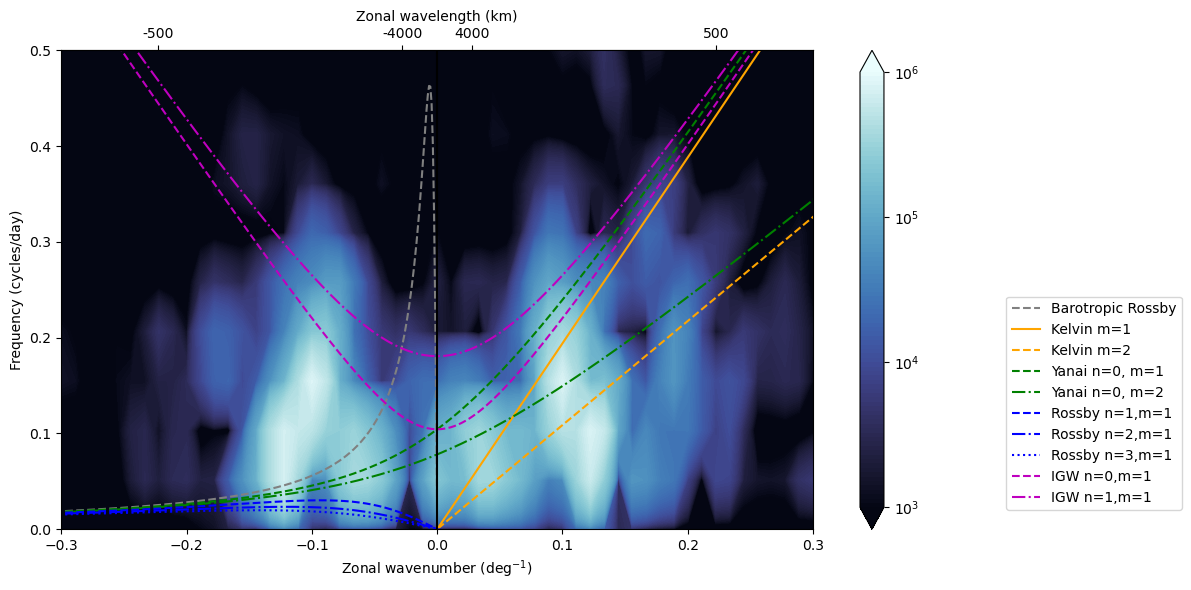

In [110]:
deg2m = 111320      # m per degree at equator

# -----------------------------
# Wavenumber array (signed)
# -----------------------------
k_deg = np.linspace(-0.5, 0.5, 1000)   # deg^-1
k_m = k_deg / deg2m                     # convert to 1/m
k_rad = 2*np.pi * k_m  # now in rad/m
omega_barotropic = -beta * k_rad / (k_rad**2 + 1 * beta / c_barotropic)  # rad/s
freq_barotropic_ross = omega_barotropic * 86400 / (2*np.pi)  # cycles/day

from matplotlib.colors import LogNorm
log_levels = np.logspace(3, 6, 100)
fig, ax = plt.subplots(figsize=(12,6))
cf = P_da_anti.plot.contourf(ax=ax,x='kx', y='omega', cmap=cmo.ice,levels=log_levels,extend='both',norm=LogNorm(vmin=1e3,vmax=1e6))

# set log scale ticks for colorbar
cbar = cf.colorbar
cbar.set_ticks([1000, 10000, 100000, 1000000])

ax.set_ylabel('Frequency (cycles/day)')
ax.set_xlabel('Zonal wavenumber (deg$^{-1}$)')
# Overlay dispersion curves
ax.plot(k_deg, freq_barotropic_ross, color='gray', linestyle='--', label='Barotropic Rossby')
ax.plot(k_deg, omega_kelvin_fn(k_rad, c1)*86400/(2*np.pi), color='orange', label='Kelvin m=1')
ax.plot(k_deg, omega_kelvin_fn(k_rad, c2)*86400/(2*np.pi), color='orange', linestyle='--',label='Kelvin m=2')
ax.plot(k_deg, omega_yanai_east(k_rad, c1, beta)*86400/(2*np.pi), color='green', linestyle='--',label='Yanai n=0, m=1')
ax.plot(k_deg, omega_yanai_east(k_rad, c2, beta)*86400/(2*np.pi), color='green', linestyle='-.', label='Yanai n=0, m=2')
ax.plot(k_deg, omega_rossby_fn(k_rad, 1, c1, beta)*86400/(2*np.pi), color='blue', linestyle='--', label='Rossby n=1,m=1')
ax.plot(k_deg, omega_rossby_fn(k_rad, 2, c1, beta)*86400/(2*np.pi), color='blue', linestyle='-.', label='Rossby n=2,m=1')
ax.plot(k_deg, omega_rossby_fn(k_rad, 3, c1, beta)*86400/(2*np.pi), color='blue', linestyle=':', label='Rossby n=3,m=1')
ax.plot(k_deg, omega_IG(k_rad, 0, c1, beta)*86400/(2*np.pi), color='m', linestyle='--', label='IGW n=0,m=1')
ax.plot(k_deg, omega_IG(k_rad, 1, c1, beta)*86400/(2*np.pi), color='m', linestyle='-.', label='IGW n=1,m=1')
# ax.plot(k_deg, omega_IG(k_rad, 0, c2, beta)*86400/(2*np.pi), color='m', linestyle=':', label='IGW n=0,m=2')
# ax.plot(k_deg, omega_IG(k_rad, 1, c2, beta)*86400/(2*np.pi), color='m', label='IGW n=1,m=2')
ax.axvline(0, color='k',label='_nolabel')
ax.legend(bbox_to_anchor=(1.5, 0.5))

# Manually set secondary x-axis ticks
km_ticks = np.array([-4000, -500, 500, 4000])  # desired top-axis tick labels in km
kdeg_for_ticks = deg2m / (1000 * km_ticks)     # convert km → k_deg
# Set secondary axis manually with fixed tick positions
secax = ax.secondary_xaxis('top')
secax.set_xticks(kdeg_for_ticks)                  # positions in deg^-1
secax.set_xticklabels([str(int(wl)) for wl in km_ticks])  # labels in km
secax.set_xlabel('Zonal wavelength (km)')

ax.set_xlim(-0.3,0.3)
ax.set_ylim(0,0.5)

plt.tight_layout()
fig.savefig(folder_name + 'k_omega_spectrum_ETAN_antisymmetric.png', dpi=300)

In [111]:
cluster.close()
client.shutdown()

2026-03-09 18:07:05,520 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-03-09 18:07:05,521 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-03-09 18:07:05,522 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-03-09 18:07:05,522 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-03-09 18:07:05,523 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-03-09 18:07:05,524 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-03-09 18:07:05,524 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-03-09 18:07:05,524 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-03-09 18:07:05,525 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-03-09